# Natural Transformations

**formalML — Category Theory Track, Topic 2**

Morphisms between functors, the Yoneda lemma, and the deep structure that connects seemingly different mathematical constructions.


## Setup


In [1]:
# Core dependencies
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from collections import defaultdict

# Consistent styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})

# Color palette (matches formalML site theme)
COLORS = {
    'primary': '#0F6E56',
    'secondary': '#534AB7',
    'accent': '#D97706',
    'danger': '#DC2626',
    'neutral': '#4B5563',
    'muted': '#9CA3AF',
    'success': '#059669',
    'functor_F': '#0F6E56',
    'functor_G': '#534AB7',
    'nat_trans': '#DC2626',
    'background': '#F9FAFB',
}

def setup_diagram_axes(ax, xlim=(-0.5, 3.5), ylim=(-0.5, 2.5), title=''):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal')
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

def draw_object(ax, pos, label, color, radius=0.15, fontsize=11):
    circle = plt.Circle(pos, radius, fill=True, facecolor='white',
                       edgecolor=color, linewidth=2, zorder=3)
    ax.add_patch(circle)
    ax.text(pos[0], pos[1], label, fontsize=fontsize, ha='center', va='center',
            color=color, fontweight='bold', zorder=4)

def draw_arrow(ax, start, end, color, label='', label_offset=(0, 0.12),
               lw=1.5, connectionstyle='arc3,rad=0.15', fontsize=10,
               linestyle='-', zorder=2):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                               connectionstyle=connectionstyle,
                               linestyle=linestyle),
                zorder=zorder)
    if label:
        mid = ((start[0]+end[0])/2 + label_offset[0],
               (start[1]+end[1])/2 + label_offset[1])
        ax.text(mid[0], mid[1], label, fontsize=fontsize, ha='center',
                va='center', color=color, zorder=5)

print("Setup complete. All helper functions defined.")


Setup complete. All helper functions defined.


---


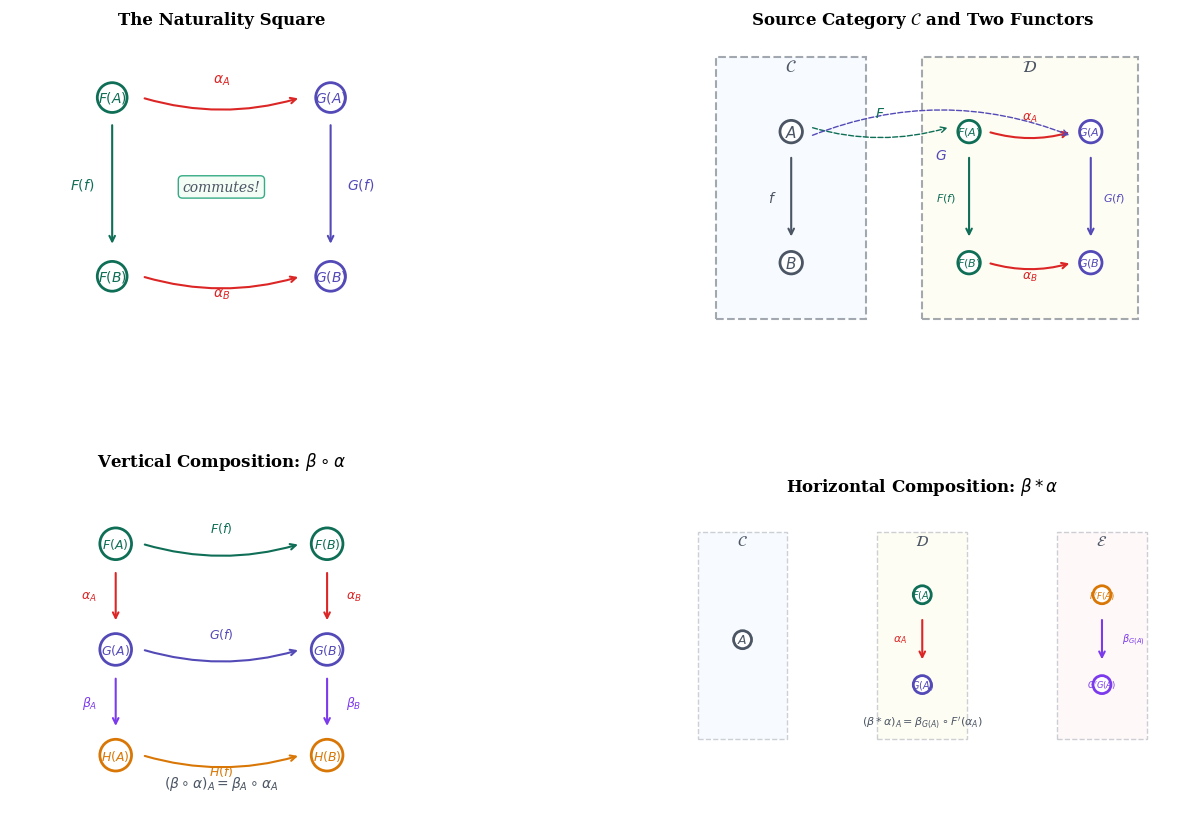

Figure 1: Natural transformation definition, composition types


In [2]:
# === Natural Transformations: Morphisms Between Functors ===
# Given two functors F, G: C -> D between the same categories,
# a natural transformation alpha: F => G is a family of morphisms
#   alpha_A: F(A) -> G(A)   for every object A in C
# such that for every morphism f: A -> B in C, the naturality square
# commutes:
#
#   F(A) --alpha_A--> G(A)
#    |                  |
#   F(f)              G(f)
#    |                  |
#    v                  v
#   F(B) --alpha_B--> G(B)
#
# That is: G(f) . alpha_A = alpha_B . F(f)
#
# The key insight: natural transformations are the RIGHT notion of
# "morphism between functors." They capture transformations that
# respect the structure of the source category -- the naturality
# condition ensures that the transformation is "uniform" across
# all objects, not dependent on any particular choice.

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# --- Panel 1: The Naturality Square ---
ax1 = fig.add_subplot(gs[0, 0])
setup_diagram_axes(ax1, xlim=(-0.3, 3.3), ylim=(-0.5, 2.8),
                   title='The Naturality Square')

draw_object(ax1, (0.4, 2.2), '$F(A)$', COLORS['functor_F'], fontsize=10)
draw_object(ax1, (2.6, 2.2), '$G(A)$', COLORS['functor_G'], fontsize=10)
draw_object(ax1, (0.4, 0.4), '$F(B)$', COLORS['functor_F'], fontsize=10)
draw_object(ax1, (2.6, 0.4), '$G(B)$', COLORS['functor_G'], fontsize=10)

draw_arrow(ax1, (0.7, 2.2), (2.3, 2.2), COLORS['nat_trans'],
           label=r'$\alpha_A$', label_offset=(0, 0.18))
draw_arrow(ax1, (0.7, 0.4), (2.3, 0.4), COLORS['nat_trans'],
           label=r'$\alpha_B$', label_offset=(0, -0.18))
draw_arrow(ax1, (0.4, 1.95), (0.4, 0.7), COLORS['functor_F'],
           label='$F(f)$', label_offset=(-0.3, 0), connectionstyle='arc3,rad=0')
draw_arrow(ax1, (2.6, 1.95), (2.6, 0.7), COLORS['functor_G'],
           label='$G(f)$', label_offset=(0.3, 0), connectionstyle='arc3,rad=0')

ax1.text(1.5, 1.3, 'commutes!', fontsize=10, ha='center', va='center',
         color=COLORS['neutral'], style='italic',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#F0FDF4',
                  edgecolor=COLORS['success'], alpha=0.8))

# --- Panel 2: Source Category + Two Functors ---
ax2 = fig.add_subplot(gs[0, 1])
setup_diagram_axes(ax2, xlim=(-0.5, 4.5), ylim=(-0.5, 3.0),
                   title=r'Source Category $\mathcal{C}$ and Two Functors')

ax2.add_patch(plt.Rectangle((-0.2, 0.0), 1.6, 2.8, fill=True,
              facecolor='#F0F9FF', edgecolor=COLORS['neutral'],
              linewidth=1.5, linestyle='--', alpha=0.5, zorder=0))
ax2.text(0.6, 2.65, r'$\mathcal{C}$', fontsize=12, ha='center',
         color=COLORS['neutral'], fontweight='bold')

draw_object(ax2, (0.6, 2.0), '$A$', COLORS['neutral'], radius=0.12)
draw_object(ax2, (0.6, 0.6), '$B$', COLORS['neutral'], radius=0.12)
draw_arrow(ax2, (0.6, 1.75), (0.6, 0.85), COLORS['neutral'],
           label='$f$', label_offset=(-0.2, 0), connectionstyle='arc3,rad=0')

ax2.add_patch(plt.Rectangle((2.0, 0.0), 2.3, 2.8, fill=True,
              facecolor='#FEFCE8', edgecolor=COLORS['neutral'],
              linewidth=1.5, linestyle='--', alpha=0.5, zorder=0))
ax2.text(3.15, 2.65, r'$\mathcal{D}$', fontsize=12, ha='center',
         color=COLORS['neutral'], fontweight='bold')

draw_object(ax2, (2.5, 2.0), '$F(A)$', COLORS['functor_F'], radius=0.12, fontsize=8)
draw_object(ax2, (3.8, 2.0), '$G(A)$', COLORS['functor_G'], radius=0.12, fontsize=8)
draw_object(ax2, (2.5, 0.6), '$F(B)$', COLORS['functor_F'], radius=0.12, fontsize=8)
draw_object(ax2, (3.8, 0.6), '$G(B)$', COLORS['functor_G'], radius=0.12, fontsize=8)

draw_arrow(ax2, (2.7, 2.0), (3.6, 2.0), COLORS['nat_trans'],
           label=r'$\alpha_A$', label_offset=(0, 0.15), fontsize=9)
draw_arrow(ax2, (2.7, 0.6), (3.6, 0.6), COLORS['nat_trans'],
           label=r'$\alpha_B$', label_offset=(0, -0.15), fontsize=9)
draw_arrow(ax2, (2.5, 1.75), (2.5, 0.85), COLORS['functor_F'],
           label='$F(f)$', label_offset=(-0.25, 0), fontsize=8,
           connectionstyle='arc3,rad=0')
draw_arrow(ax2, (3.8, 1.75), (3.8, 0.85), COLORS['functor_G'],
           label='$G(f)$', label_offset=(0.25, 0), fontsize=8,
           connectionstyle='arc3,rad=0')

draw_arrow(ax2, (0.8, 2.05), (2.3, 2.05), COLORS['functor_F'],
           label='$F$', label_offset=(0, 0.15), linestyle='--', lw=1)
draw_arrow(ax2, (0.8, 1.95), (3.6, 1.95), COLORS['functor_G'],
           label='$G$', label_offset=(0, -0.2), linestyle='--', lw=1,
           connectionstyle='arc3,rad=-0.2')

# --- Panel 3: Vertical Composition ---
ax3 = fig.add_subplot(gs[1, 0])
setup_diagram_axes(ax3, xlim=(-0.5, 3.5), ylim=(-0.3, 2.8),
                   title=r'Vertical Composition: $\beta \circ \alpha$')

draw_object(ax3, (0.5, 2.2), '$F(A)$', COLORS['functor_F'], fontsize=9)
draw_object(ax3, (0.5, 1.2), '$G(A)$', COLORS['functor_G'], fontsize=9)
draw_object(ax3, (0.5, 0.2), '$H(A)$', COLORS['accent'], fontsize=9)
draw_object(ax3, (2.5, 2.2), '$F(B)$', COLORS['functor_F'], fontsize=9)
draw_object(ax3, (2.5, 1.2), '$G(B)$', COLORS['functor_G'], fontsize=9)
draw_object(ax3, (2.5, 0.2), '$H(B)$', COLORS['accent'], fontsize=9)

draw_arrow(ax3, (0.5, 1.95), (0.5, 1.45), COLORS['nat_trans'],
           label=r'$\alpha_A$', label_offset=(-0.25, 0), fontsize=9,
           connectionstyle='arc3,rad=0')
draw_arrow(ax3, (2.5, 1.95), (2.5, 1.45), COLORS['nat_trans'],
           label=r'$\alpha_B$', label_offset=(0.25, 0), fontsize=9,
           connectionstyle='arc3,rad=0')
draw_arrow(ax3, (0.5, 0.95), (0.5, 0.45), '#7C3AED',
           label=r'$\beta_A$', label_offset=(-0.25, 0), fontsize=9,
           connectionstyle='arc3,rad=0')
draw_arrow(ax3, (2.5, 0.95), (2.5, 0.45), '#7C3AED',
           label=r'$\beta_B$', label_offset=(0.25, 0), fontsize=9,
           connectionstyle='arc3,rad=0')
draw_arrow(ax3, (0.75, 2.2), (2.25, 2.2), COLORS['functor_F'],
           label='$F(f)$', label_offset=(0, 0.15), fontsize=9)
draw_arrow(ax3, (0.75, 1.2), (2.25, 1.2), COLORS['functor_G'],
           label='$G(f)$', label_offset=(0, 0.15), fontsize=9)
draw_arrow(ax3, (0.75, 0.2), (2.25, 0.2), COLORS['accent'],
           label='$H(f)$', label_offset=(0, -0.15), fontsize=9)

ax3.text(1.5, -0.1, r'$(\beta \circ \alpha)_A = \beta_A \circ \alpha_A$',
         fontsize=10, ha='center', color=COLORS['neutral'])

# --- Panel 4: Horizontal Composition ---
ax4 = fig.add_subplot(gs[1, 1])
setup_diagram_axes(ax4, xlim=(-0.5, 5.5), ylim=(-0.3, 2.8),
                   title=r'Horizontal Composition: $\beta * \alpha$')

for x, label, col in [(0.5, r'$\mathcal{C}$', '#F0F9FF'),
                       (2.5, r'$\mathcal{D}$', '#FEFCE8'),
                       (4.5, r'$\mathcal{E}$', '#FEF2F2')]:
    ax4.add_patch(plt.Rectangle((x-0.5, 0.2), 1.0, 2.3, fill=True,
                  facecolor=col, edgecolor=COLORS['muted'],
                  linewidth=1, linestyle='--', alpha=0.5, zorder=0))
    ax4.text(x, 2.35, label, fontsize=11, ha='center',
             color=COLORS['neutral'], fontweight='bold')

draw_object(ax4, (0.5, 1.3), '$A$', COLORS['neutral'], radius=0.1, fontsize=9)
draw_object(ax4, (2.5, 1.8), '$F(A)$', COLORS['functor_F'], radius=0.1, fontsize=7)
draw_object(ax4, (2.5, 0.8), '$G(A)$', COLORS['functor_G'], radius=0.1, fontsize=7)
draw_object(ax4, (4.5, 1.8), "$F'F(A)$", COLORS['accent'], radius=0.1, fontsize=6)
draw_object(ax4, (4.5, 0.8), "$G'G(A)$", '#7C3AED', radius=0.1, fontsize=6)

draw_arrow(ax4, (2.5, 1.55), (2.5, 1.05), COLORS['nat_trans'],
           label=r'$\alpha_A$', label_offset=(-0.25, 0), fontsize=8,
           connectionstyle='arc3,rad=0')
draw_arrow(ax4, (4.5, 1.55), (4.5, 1.05), '#7C3AED',
           label=r"$\beta_{G(A)}$", label_offset=(0.35, 0), fontsize=7,
           connectionstyle='arc3,rad=0')

ax4.text(2.5, 0.35, r"$(\beta * \alpha)_A = \beta_{G(A)} \circ F'(\alpha_A)$",
         fontsize=8, ha='center', color=COLORS['neutral'])

plt.savefig('natural-transformations-definition.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Figure 1: Natural transformation definition, composition types")


---


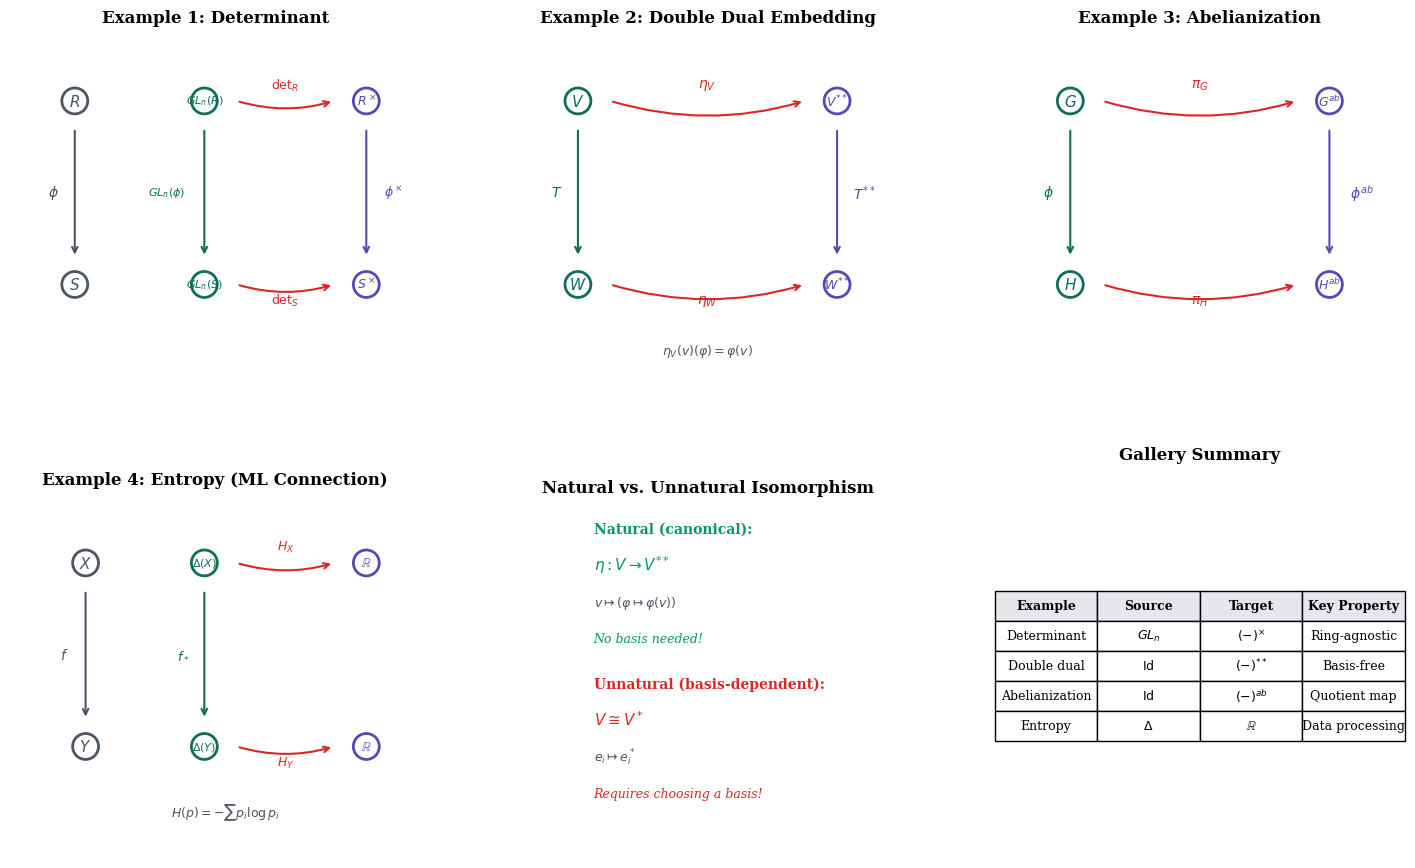

Figure 2: Gallery of natural transformations


In [3]:
# === A Gallery of Natural Transformations ===
# Natural transformations appear everywhere once we know what to look for.
#
# Example 1: The determinant
#   GL_n: Ring -> Grp sends R to GL_n(R), phi to GL_n(phi)
#   (-)^x: Ring -> Grp sends R to R^x (units), phi to phi|_{R^x}
#   det: GL_n => (-)^x is a natural transformation
#
# Example 2: The double dual embedding
#   Id: Vec -> Vec (identity functor)
#   (-)**:  Vec -> Vec (double dual)
#   eta: Id => (-)** sends v to (phi |-> phi(v))
#   This is NATURAL (basis-free), unlike V ~ V* which requires a basis.
#
# Example 3: Abelianization
#   pi: Id_Grp => Ab sends G to G/[G,G]
#
# Example 4: Entropy (ML connection)
#   H: Delta => R sends probability distributions to their entropy
#   Naturality relates to the data processing inequality.
#
# Example 5: The "components" functor (set theory)
#   pi_0: Top -> Set sends a space to its set of connected components.

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# --- Panel 1: Determinant ---
ax = axes[0, 0]
setup_diagram_axes(ax, xlim=(-0.3, 3.5), ylim=(-0.3, 2.8),
                   title='Example 1: Determinant')

draw_object(ax, (0.3, 2.2), '$R$', COLORS['neutral'], radius=0.12)
draw_object(ax, (0.3, 0.5), '$S$', COLORS['neutral'], radius=0.12)
draw_arrow(ax, (0.3, 1.95), (0.3, 0.75), COLORS['neutral'],
           label=r'$\phi$', label_offset=(-0.2, 0), connectionstyle='arc3,rad=0')

draw_object(ax, (1.5, 2.2), r'$GL_n(R)$', COLORS['functor_F'], radius=0.12, fontsize=8)
draw_object(ax, (1.5, 0.5), r'$GL_n(S)$', COLORS['functor_F'], radius=0.12, fontsize=8)
draw_object(ax, (3.0, 2.2), r'$R^\times$', COLORS['functor_G'], radius=0.12, fontsize=9)
draw_object(ax, (3.0, 0.5), r'$S^\times$', COLORS['functor_G'], radius=0.12, fontsize=9)

draw_arrow(ax, (1.8, 2.2), (2.7, 2.2), COLORS['nat_trans'],
           label=r'$\det_R$', label_offset=(0, 0.15), fontsize=9)
draw_arrow(ax, (1.8, 0.5), (2.7, 0.5), COLORS['nat_trans'],
           label=r'$\det_S$', label_offset=(0, -0.15), fontsize=9)
draw_arrow(ax, (1.5, 1.95), (1.5, 0.75), COLORS['functor_F'],
           label=r'$GL_n(\phi)$', label_offset=(-0.35, 0), fontsize=8,
           connectionstyle='arc3,rad=0')
draw_arrow(ax, (3.0, 1.95), (3.0, 0.75), COLORS['functor_G'],
           label=r'$\phi^\times$', label_offset=(0.25, 0), fontsize=9,
           connectionstyle='arc3,rad=0')

# --- Panel 2: Double Dual ---
ax = axes[0, 1]
setup_diagram_axes(ax, xlim=(-0.3, 3.5), ylim=(-0.3, 2.8),
                   title='Example 2: Double Dual Embedding')

draw_object(ax, (0.4, 2.2), '$V$', COLORS['functor_F'], radius=0.12)
draw_object(ax, (0.4, 0.5), '$W$', COLORS['functor_F'], radius=0.12)
draw_object(ax, (2.8, 2.2), '$V^{**}$', COLORS['functor_G'], radius=0.12, fontsize=9)
draw_object(ax, (2.8, 0.5), '$W^{**}$', COLORS['functor_G'], radius=0.12, fontsize=9)

draw_arrow(ax, (0.7, 2.2), (2.5, 2.2), COLORS['nat_trans'],
           label=r'$\eta_V$', label_offset=(0, 0.15))
draw_arrow(ax, (0.7, 0.5), (2.5, 0.5), COLORS['nat_trans'],
           label=r'$\eta_W$', label_offset=(0, -0.15))
draw_arrow(ax, (0.4, 1.95), (0.4, 0.75), COLORS['functor_F'],
           label='$T$', label_offset=(-0.2, 0), connectionstyle='arc3,rad=0')
draw_arrow(ax, (2.8, 1.95), (2.8, 0.75), COLORS['functor_G'],
           label='$T^{**}$', label_offset=(0.25, 0), connectionstyle='arc3,rad=0')

ax.text(1.6, -0.15, r'$\eta_V(v)(\varphi) = \varphi(v)$', fontsize=9,
        ha='center', color=COLORS['neutral'])

# --- Panel 3: Abelianization ---
ax = axes[0, 2]
setup_diagram_axes(ax, xlim=(-0.3, 3.5), ylim=(-0.3, 2.8),
                   title='Example 3: Abelianization')

draw_object(ax, (0.4, 2.2), '$G$', COLORS['functor_F'], radius=0.12)
draw_object(ax, (0.4, 0.5), '$H$', COLORS['functor_F'], radius=0.12)
draw_object(ax, (2.8, 2.2), '$G^{ab}$', COLORS['functor_G'], radius=0.12, fontsize=9)
draw_object(ax, (2.8, 0.5), '$H^{ab}$', COLORS['functor_G'], radius=0.12, fontsize=9)

draw_arrow(ax, (0.7, 2.2), (2.5, 2.2), COLORS['nat_trans'],
           label=r'$\pi_G$', label_offset=(0, 0.15))
draw_arrow(ax, (0.7, 0.5), (2.5, 0.5), COLORS['nat_trans'],
           label=r'$\pi_H$', label_offset=(0, -0.15))
draw_arrow(ax, (0.4, 1.95), (0.4, 0.75), COLORS['functor_F'],
           label=r'$\phi$', label_offset=(-0.2, 0), connectionstyle='arc3,rad=0')
draw_arrow(ax, (2.8, 1.95), (2.8, 0.75), COLORS['functor_G'],
           label=r'$\phi^{ab}$', label_offset=(0.3, 0), connectionstyle='arc3,rad=0')

# --- Panel 4: Entropy ---
ax = axes[1, 0]
setup_diagram_axes(ax, xlim=(-0.3, 3.5), ylim=(-0.3, 2.8),
                   title='Example 4: Entropy (ML Connection)')

draw_object(ax, (0.4, 2.2), '$X$', COLORS['neutral'], radius=0.12)
draw_object(ax, (0.4, 0.5), '$Y$', COLORS['neutral'], radius=0.12)
draw_arrow(ax, (0.4, 1.95), (0.4, 0.75), COLORS['neutral'],
           label='$f$', label_offset=(-0.2, 0), connectionstyle='arc3,rad=0')

draw_object(ax, (1.5, 2.2), r'$\Delta(X)$', COLORS['functor_F'], radius=0.12, fontsize=8)
draw_object(ax, (1.5, 0.5), r'$\Delta(Y)$', COLORS['functor_F'], radius=0.12, fontsize=8)
draw_object(ax, (3.0, 2.2), r'$\mathbb{R}$', COLORS['functor_G'], radius=0.12, fontsize=9)
draw_object(ax, (3.0, 0.5), r'$\mathbb{R}$', COLORS['functor_G'], radius=0.12, fontsize=9)

draw_arrow(ax, (1.8, 2.2), (2.7, 2.2), COLORS['nat_trans'],
           label=r'$H_X$', label_offset=(0, 0.15), fontsize=9)
draw_arrow(ax, (1.8, 0.5), (2.7, 0.5), COLORS['nat_trans'],
           label=r'$H_Y$', label_offset=(0, -0.15), fontsize=9)
draw_arrow(ax, (1.5, 1.95), (1.5, 0.75), COLORS['functor_F'],
           label=r'$f_*$', label_offset=(-0.2, 0), fontsize=9,
           connectionstyle='arc3,rad=0')

ax.text(1.7, -0.15, r'$H(p) = -\sum p_i \log p_i$', fontsize=9,
        ha='center', color=COLORS['neutral'])

# --- Panel 5: Natural vs Unnatural ---
ax = axes[1, 1]
setup_diagram_axes(ax, xlim=(-0.5, 4.0), ylim=(-0.5, 3.0),
                   title='Natural vs. Unnatural Isomorphism')

ax.text(0.5, 2.7, 'Natural (canonical):', fontsize=10, fontweight='bold',
        color=COLORS['success'])
ax.text(0.5, 2.3, r'$\eta: V \to V^{**}$', fontsize=11, color=COLORS['success'])
ax.text(0.5, 1.9, r'$v \mapsto (\varphi \mapsto \varphi(v))$', fontsize=9,
        color=COLORS['neutral'])
ax.text(0.5, 1.5, 'No basis needed!', fontsize=9, color=COLORS['success'],
        style='italic')

ax.text(0.5, 1.0, 'Unnatural (basis-dependent):', fontsize=10, fontweight='bold',
        color=COLORS['danger'])
ax.text(0.5, 0.6, r'$V \cong V^*$', fontsize=11, color=COLORS['danger'])
ax.text(0.5, 0.2, r'$e_i \mapsto e_i^*$', fontsize=9, color=COLORS['neutral'])
ax.text(0.5, -0.2, 'Requires choosing a basis!', fontsize=9,
        color=COLORS['danger'], style='italic')

# --- Panel 6: Summary ---
ax = axes[1, 2]
ax.axis('off')
ax.set_title('Gallery Summary', fontsize=12, fontweight='bold', pad=10)

table_data = [
    ['Example', 'Source', 'Target', 'Key Property'],
    ['Determinant', '$GL_n$', '$(-)^{\\times}$', 'Ring-agnostic'],
    ['Double dual', '$\\mathrm{Id}$', '$(-)^{**}$', 'Basis-free'],
    ['Abelianization', '$\\mathrm{Id}$', '$(-)^{ab}$', 'Quotient map'],
    ['Entropy', '$\\Delta$', '$\\mathbb{R}$', 'Data processing'],
]

table = ax.table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.8)
for j in range(4):
    table[0, j].set_facecolor('#E5E7EB')
    table[0, j].set_text_props(fontweight='bold')

plt.savefig('natural-transformations-gallery.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Figure 2: Gallery of natural transformations")


---


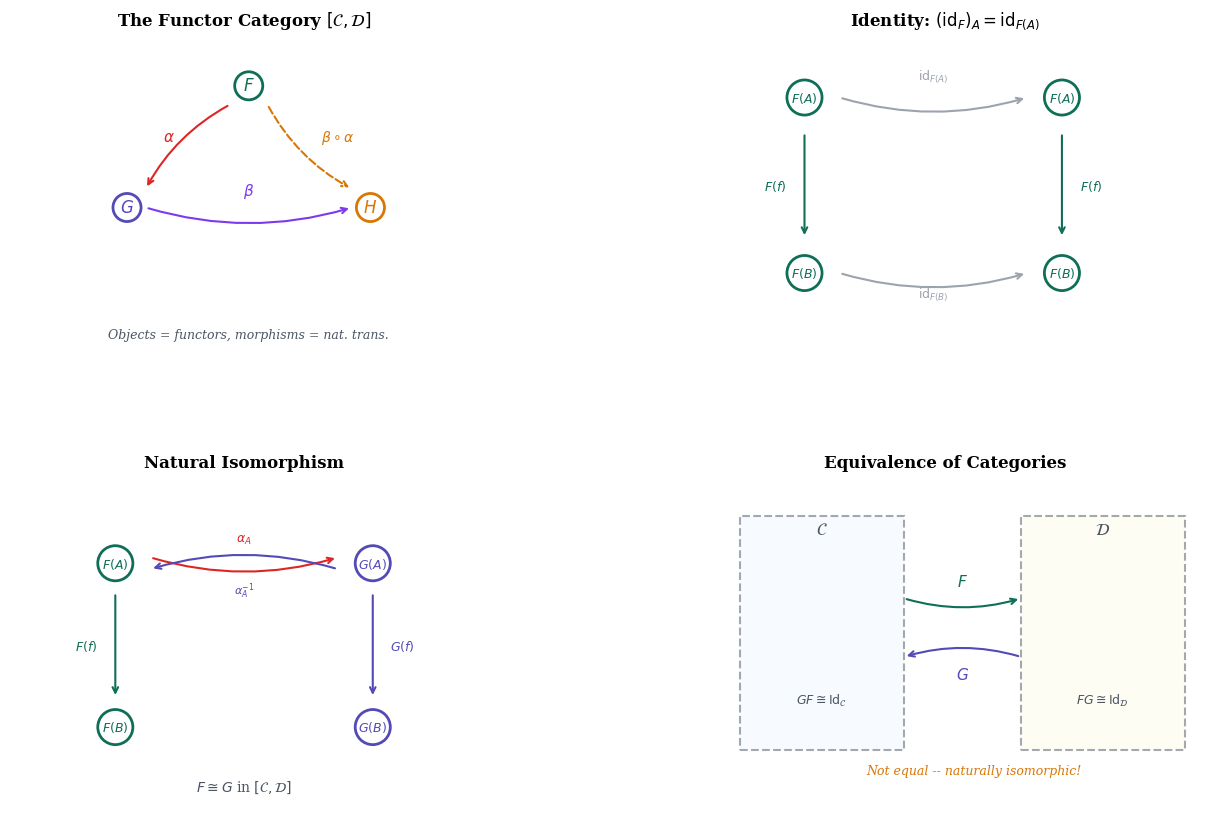

Figure 3: Functor categories and equivalences


In [4]:
# === Functor Categories ===
# Given categories C and D, the functor category [C, D] has:
#   - Objects: functors F: C -> D
#   - Morphisms: natural transformations alpha: F => G
#   - Composition: vertical composition (componentwise in D)
#   - Identity: (id_F)_A = id_{F(A)}
#
# Natural isomorphism: alpha: F => G where every alpha_A is invertible.
#
# Equivalence of categories: F: C -> D and G: D -> C with natural
# isomorphisms GF ~ Id_C and FG ~ Id_D. This is the RIGHT notion
# of "sameness" for categories -- much weaker than isomorphism.

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# --- Panel 1: Functor category ---
ax1 = fig.add_subplot(gs[0, 0])
setup_diagram_axes(ax1, xlim=(-0.5, 4.0), ylim=(-0.5, 3.0),
                   title=r'The Functor Category $[\mathcal{C}, \mathcal{D}]$')

draw_object(ax1, (1.8, 2.5), '$F$', COLORS['functor_F'], radius=0.15, fontsize=12)
draw_object(ax1, (0.5, 1.2), '$G$', COLORS['functor_G'], radius=0.15, fontsize=12)
draw_object(ax1, (3.1, 1.2), '$H$', COLORS['accent'], radius=0.15, fontsize=12)

draw_arrow(ax1, (1.6, 2.3), (0.7, 1.4), COLORS['nat_trans'],
           label=r'$\alpha$', label_offset=(-0.2, 0.1), fontsize=11)
draw_arrow(ax1, (0.7, 1.2), (2.9, 1.2), '#7C3AED',
           label=r'$\beta$', label_offset=(0, 0.18), fontsize=11)
draw_arrow(ax1, (2.0, 2.3), (2.9, 1.4), COLORS['accent'],
           label=r'$\beta \circ \alpha$', label_offset=(0.3, 0.1), fontsize=10,
           linestyle='--')

ax1.text(1.8, -0.2, 'Objects = functors, morphisms = nat. trans.',
         fontsize=9, ha='center', color=COLORS['neutral'], style='italic')

# --- Panel 2: Identity ---
ax2 = fig.add_subplot(gs[0, 1])
setup_diagram_axes(ax2, xlim=(-0.3, 3.3), ylim=(-0.3, 2.5),
                   title=r'Identity: $(\mathrm{id}_F)_A = \mathrm{id}_{F(A)}$')

draw_object(ax2, (0.3, 2.0), '$F(A)$', COLORS['functor_F'], fontsize=9)
draw_object(ax2, (2.5, 2.0), '$F(A)$', COLORS['functor_F'], fontsize=9)
draw_object(ax2, (0.3, 0.5), '$F(B)$', COLORS['functor_F'], fontsize=9)
draw_object(ax2, (2.5, 0.5), '$F(B)$', COLORS['functor_F'], fontsize=9)

draw_arrow(ax2, (0.6, 2.0), (2.2, 2.0), COLORS['muted'],
           label=r'$\mathrm{id}_{F(A)}$', label_offset=(0, 0.18), fontsize=9)
draw_arrow(ax2, (0.6, 0.5), (2.2, 0.5), COLORS['muted'],
           label=r'$\mathrm{id}_{F(B)}$', label_offset=(0, -0.18), fontsize=9)
draw_arrow(ax2, (0.3, 1.7), (0.3, 0.8), COLORS['functor_F'],
           label='$F(f)$', label_offset=(-0.25, 0), fontsize=9,
           connectionstyle='arc3,rad=0')
draw_arrow(ax2, (2.5, 1.7), (2.5, 0.8), COLORS['functor_F'],
           label='$F(f)$', label_offset=(0.25, 0), fontsize=9,
           connectionstyle='arc3,rad=0')

# --- Panel 3: Natural isomorphism ---
ax3 = fig.add_subplot(gs[1, 0])
setup_diagram_axes(ax3, xlim=(-0.5, 3.5), ylim=(-0.3, 2.5),
                   title='Natural Isomorphism')

draw_object(ax3, (0.4, 1.8), '$F(A)$', COLORS['functor_F'], fontsize=9)
draw_object(ax3, (2.6, 1.8), '$G(A)$', COLORS['functor_G'], fontsize=9)
draw_object(ax3, (0.4, 0.4), '$F(B)$', COLORS['functor_F'], fontsize=9)
draw_object(ax3, (2.6, 0.4), '$G(B)$', COLORS['functor_G'], fontsize=9)

draw_arrow(ax3, (0.7, 1.85), (2.3, 1.85), COLORS['nat_trans'],
           label=r'$\alpha_A$', label_offset=(0, 0.15), fontsize=9)
draw_arrow(ax3, (2.3, 1.75), (0.7, 1.75), COLORS['functor_G'],
           label=r'$\alpha_A^{-1}$', label_offset=(0, -0.18), fontsize=8)
draw_arrow(ax3, (0.4, 1.55), (0.4, 0.65), COLORS['functor_F'],
           label='$F(f)$', label_offset=(-0.25, 0), fontsize=9,
           connectionstyle='arc3,rad=0')
draw_arrow(ax3, (2.6, 1.55), (2.6, 0.65), COLORS['functor_G'],
           label='$G(f)$', label_offset=(0.25, 0), fontsize=9,
           connectionstyle='arc3,rad=0')
ax3.text(1.5, -0.15, r'$F \cong G$ in $[\mathcal{C}, \mathcal{D}]$',
         fontsize=10, ha='center', color=COLORS['neutral'])

# --- Panel 4: Equivalence of categories ---
ax4 = fig.add_subplot(gs[1, 1])
setup_diagram_axes(ax4, xlim=(-0.5, 4.0), ylim=(-0.3, 2.5),
                   title='Equivalence of Categories')

ax4.add_patch(plt.Rectangle((0.0, 0.2), 1.4, 2.0, fill=True,
              facecolor='#F0F9FF', edgecolor=COLORS['neutral'],
              linewidth=1.5, linestyle='--', alpha=0.5))
ax4.text(0.7, 2.05, r'$\mathcal{C}$', fontsize=12, ha='center',
         color=COLORS['neutral'], fontweight='bold')

ax4.add_patch(plt.Rectangle((2.4, 0.2), 1.4, 2.0, fill=True,
              facecolor='#FEFCE8', edgecolor=COLORS['neutral'],
              linewidth=1.5, linestyle='--', alpha=0.5))
ax4.text(3.1, 2.05, r'$\mathcal{D}$', fontsize=12, ha='center',
         color=COLORS['neutral'], fontweight='bold')

draw_arrow(ax4, (1.4, 1.5), (2.4, 1.5), COLORS['functor_F'],
           label='$F$', label_offset=(0, 0.15), fontsize=11)
draw_arrow(ax4, (2.4, 1.0), (1.4, 1.0), COLORS['functor_G'],
           label='$G$', label_offset=(0, -0.15), fontsize=11)

ax4.text(0.7, 0.6, r'$GF \cong \mathrm{Id}_\mathcal{C}$', fontsize=9,
         ha='center', color=COLORS['neutral'])
ax4.text(3.1, 0.6, r'$FG \cong \mathrm{Id}_\mathcal{D}$', fontsize=9,
         ha='center', color=COLORS['neutral'])
ax4.text(2.0, 0.0, 'Not equal -- naturally isomorphic!', fontsize=9,
         ha='center', color=COLORS['accent'], style='italic')

plt.savefig('functor-categories.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 3: Functor categories and equivalences")


---


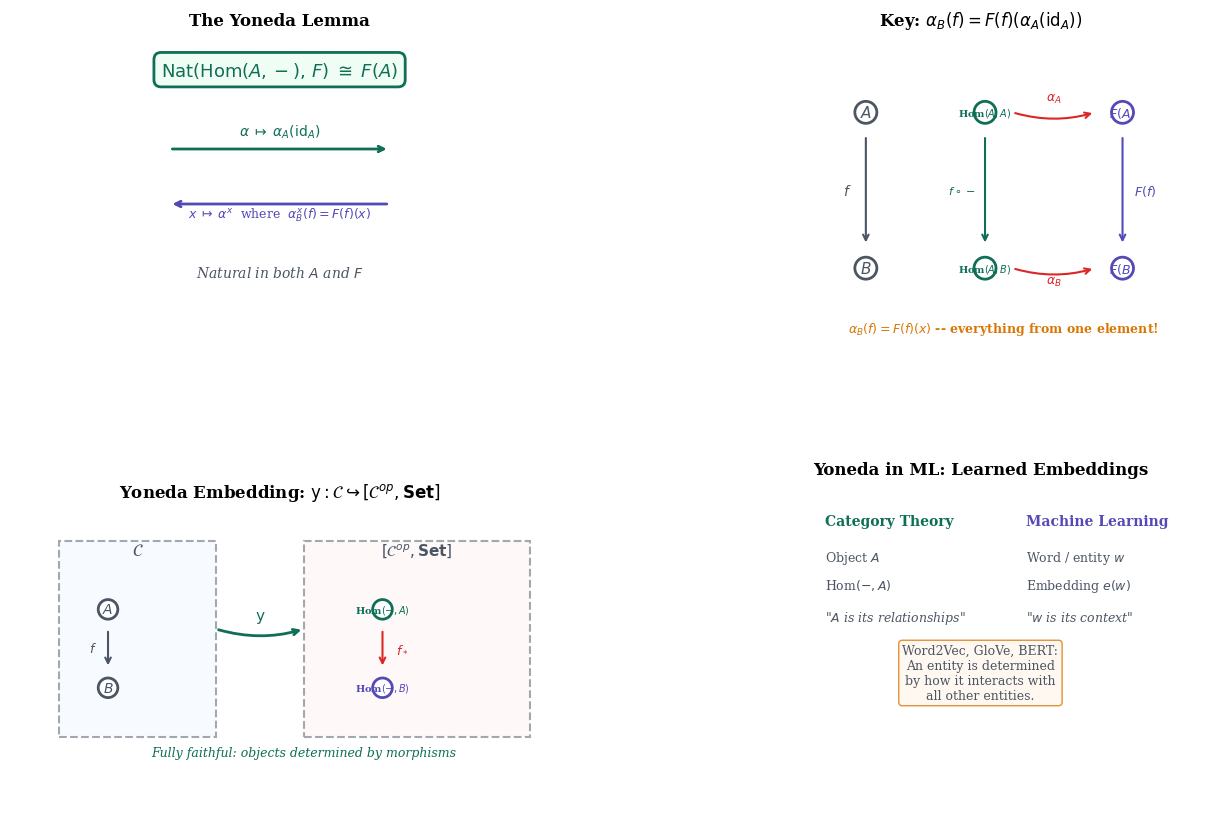

Figure 4: The Yoneda lemma and consequences


In [5]:
# === The Yoneda Lemma ===
# The most important result in basic category theory.
#
# Statement: For a locally small category C, functor F: C -> Set,
# and object A of C:
#   Nat(Hom(A, -), F)  ~=  F(A)
# natural in both A and F.
#
# The bijection: alpha |-> alpha_A(id_A)   (the "Yoneda element")
# The inverse:   x |-> alpha^x  where  alpha^x_B(f) = F(f)(x)
#
# Consequences:
# 1. Yoneda Embedding y: C -> [C^op, Set] is fully faithful
#    "An object is determined by its relationships"
# 2. Representable functors are determined by universal elements
# 3. Connection to ML: distributional semantics, embeddings

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)

# --- Panel 1: The bijection ---
ax1 = fig.add_subplot(gs[0, 0])
setup_diagram_axes(ax1, xlim=(-0.5, 4.5), ylim=(-0.5, 3.0),
                   title='The Yoneda Lemma')

ax1.text(2.0, 2.6, r'$\mathrm{Nat}(\mathrm{Hom}(A, -),\, F) \;\cong\; F(A)$',
         fontsize=13, ha='center', color=COLORS['primary'], fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0FDF4',
                  edgecolor=COLORS['primary'], linewidth=2))

ax1.annotate('', xy=(3.2, 1.8), xytext=(0.8, 1.8),
             arrowprops=dict(arrowstyle='->', color=COLORS['functor_F'], lw=2))
ax1.text(2.0, 1.95, r'$\alpha \;\mapsto\; \alpha_A(\mathrm{id}_A)$',
         fontsize=10, ha='center', color=COLORS['functor_F'])

ax1.annotate('', xy=(0.8, 1.2), xytext=(3.2, 1.2),
             arrowprops=dict(arrowstyle='->', color=COLORS['functor_G'], lw=2))
ax1.text(2.0, 1.05, r'$x \;\mapsto\; \alpha^x$  where  $\alpha^x_B(f) = F(f)(x)$',
         fontsize=9, ha='center', color=COLORS['functor_G'])

ax1.text(2.0, 0.4, 'Natural in both $A$ and $F$', fontsize=10, ha='center',
         color=COLORS['neutral'], style='italic')

# --- Panel 2: How it works ---
ax2 = fig.add_subplot(gs[0, 1])
setup_diagram_axes(ax2, xlim=(-0.5, 4.0), ylim=(-0.5, 3.0),
                   title=r'Key: $\alpha_B(f) = F(f)(\alpha_A(\mathrm{id}_A))$')

draw_object(ax2, (0.5, 2.2), '$A$', COLORS['neutral'], radius=0.12)
draw_object(ax2, (0.5, 0.5), '$B$', COLORS['neutral'], radius=0.12)
draw_arrow(ax2, (0.5, 1.95), (0.5, 0.75), COLORS['neutral'],
           label='$f$', label_offset=(-0.2, 0), connectionstyle='arc3,rad=0')

draw_object(ax2, (1.8, 2.2), r'Hom$(A,A)$', COLORS['functor_F'],
            radius=0.12, fontsize=7)
draw_object(ax2, (1.8, 0.5), r'Hom$(A,B)$', COLORS['functor_F'],
            radius=0.12, fontsize=7)
draw_arrow(ax2, (1.8, 1.95), (1.8, 0.75), COLORS['functor_F'],
           label=r'$f \circ -$', label_offset=(-0.25, 0), fontsize=8,
           connectionstyle='arc3,rad=0')

draw_object(ax2, (3.3, 2.2), '$F(A)$', COLORS['functor_G'], radius=0.12, fontsize=9)
draw_object(ax2, (3.3, 0.5), '$F(B)$', COLORS['functor_G'], radius=0.12, fontsize=9)
draw_arrow(ax2, (3.3, 1.95), (3.3, 0.75), COLORS['functor_G'],
           label='$F(f)$', label_offset=(0.25, 0), fontsize=9,
           connectionstyle='arc3,rad=0')

draw_arrow(ax2, (2.1, 2.2), (3.0, 2.2), COLORS['nat_trans'],
           label=r'$\alpha_A$', label_offset=(0, 0.15), fontsize=9)
draw_arrow(ax2, (2.1, 0.5), (3.0, 0.5), COLORS['nat_trans'],
           label=r'$\alpha_B$', label_offset=(0, -0.15), fontsize=9)

ax2.text(2.0, -0.2, r'$\alpha_B(f) = F(f)(x)$ -- everything from one element!',
         fontsize=9, ha='center', color=COLORS['accent'], fontweight='bold')

# --- Panel 3: Yoneda Embedding ---
ax3 = fig.add_subplot(gs[1, 0])
setup_diagram_axes(ax3, xlim=(-0.5, 5.0), ylim=(-0.3, 2.5),
                   title=r'Yoneda Embedding: $\mathsf{y}: \mathcal{C} \hookrightarrow [\mathcal{C}^{op}, \mathbf{Set}]$')

ax3.add_patch(plt.Rectangle((0.0, 0.2), 1.6, 2.0, fill=True,
              facecolor='#F0F9FF', edgecolor=COLORS['neutral'],
              linewidth=1.5, linestyle='--', alpha=0.5))
ax3.text(0.8, 2.05, r'$\mathcal{C}$', fontsize=12, ha='center',
         color=COLORS['neutral'], fontweight='bold')

ax3.add_patch(plt.Rectangle((2.5, 0.2), 2.3, 2.0, fill=True,
              facecolor='#FEF2F2', edgecolor=COLORS['neutral'],
              linewidth=1.5, linestyle='--', alpha=0.5))
ax3.text(3.65, 2.05, r'$[\mathcal{C}^{op}, \mathbf{Set}]$', fontsize=11, ha='center',
         color=COLORS['neutral'], fontweight='bold')

draw_object(ax3, (0.5, 1.5), '$A$', COLORS['neutral'], radius=0.1, fontsize=10)
draw_object(ax3, (0.5, 0.7), '$B$', COLORS['neutral'], radius=0.1, fontsize=10)
draw_arrow(ax3, (0.5, 1.3), (0.5, 0.9), COLORS['neutral'],
           label='$f$', label_offset=(-0.15, 0), fontsize=9,
           connectionstyle='arc3,rad=0')

draw_object(ax3, (3.3, 1.5), r'Hom$(-,A)$', COLORS['functor_F'],
            radius=0.1, fontsize=7)
draw_object(ax3, (3.3, 0.7), r'Hom$(-,B)$', COLORS['functor_G'],
            radius=0.1, fontsize=7)
draw_arrow(ax3, (3.3, 1.3), (3.3, 0.9), COLORS['nat_trans'],
           label=r'$f_*$', label_offset=(0.2, 0), fontsize=9,
           connectionstyle='arc3,rad=0')

draw_arrow(ax3, (1.6, 1.3), (2.5, 1.3), COLORS['primary'],
           label=r'$\mathsf{y}$', label_offset=(0, 0.12), fontsize=11, lw=2)

ax3.text(2.5, 0.0, 'Fully faithful: objects determined by morphisms',
         fontsize=9, ha='center', color=COLORS['primary'], style='italic')

# --- Panel 4: ML Connection ---
ax4 = fig.add_subplot(gs[1, 1])
setup_diagram_axes(ax4, xlim=(-0.5, 4.5), ylim=(-0.5, 3.0),
                   title='Yoneda in ML: Learned Embeddings')

ax4.text(0.3, 2.6, 'Category Theory', fontsize=10, fontweight='bold',
         color=COLORS['primary'])
ax4.text(0.3, 2.2, r'Object $A$', fontsize=9, color=COLORS['neutral'])
ax4.text(0.3, 1.9, r'Hom$(-, A)$', fontsize=9, color=COLORS['neutral'])
ax4.text(0.3, 1.55, '"$A$ is its relationships"', fontsize=9,
         color=COLORS['neutral'], style='italic')

ax4.text(2.5, 2.6, 'Machine Learning', fontsize=10, fontweight='bold',
         color=COLORS['functor_G'])
ax4.text(2.5, 2.2, 'Word / entity $w$', fontsize=9, color=COLORS['neutral'])
ax4.text(2.5, 1.9, 'Embedding $e(w)$', fontsize=9, color=COLORS['neutral'])
ax4.text(2.5, 1.55, '"$w$ is its context"', fontsize=9,
         color=COLORS['neutral'], style='italic')

ax4.text(2.0, 0.7, 'Word2Vec, GloVe, BERT:\nAn entity is determined\n'
         'by how it interacts with\nall other entities.',
         fontsize=9, ha='center', color=COLORS['neutral'],
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF7ED',
                  edgecolor=COLORS['accent'], alpha=0.8))

plt.savefig('yoneda-lemma.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4: The Yoneda lemma and consequences")


---


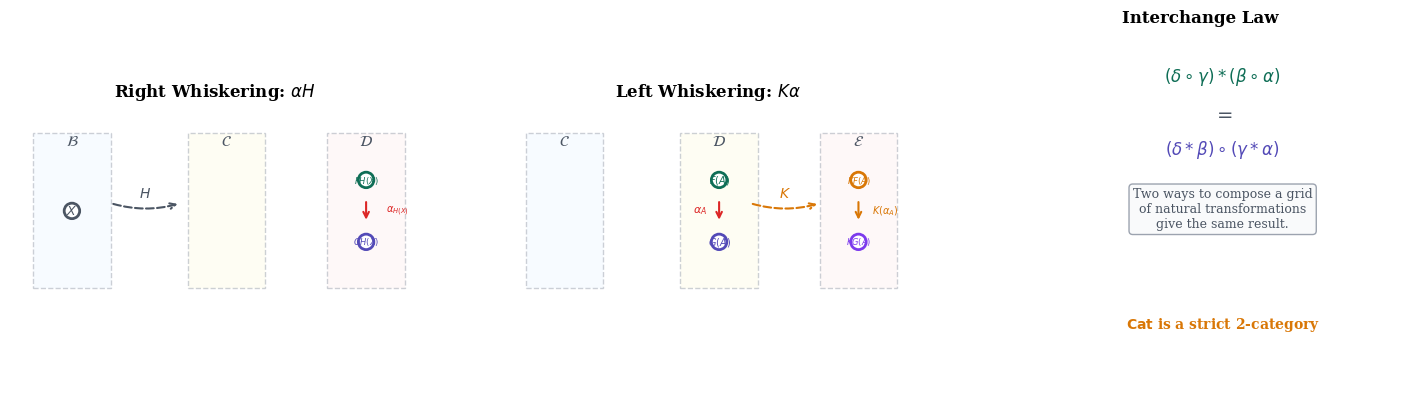

Figure 5: Whiskering, interchange law, 2-categories


In [6]:
# === Whiskering, Interchange, and 2-Categories ===
# Vertical and horizontal composition satisfy the interchange law:
#   (delta . gamma) * (beta . alpha) = (delta * beta) . (gamma * alpha)
#
# Whiskering:
#   Right: alpha * id_H = alpha H (pre-compose with H)
#   Left:  id_K * alpha = K alpha (post-compose with K)
#
# Cat is a 2-category: 0-cells = categories, 1-cells = functors,
# 2-cells = natural transformations.

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Panel 1: Right Whiskering ---
ax = axes[0]
setup_diagram_axes(ax, xlim=(-0.3, 5.0), ylim=(-0.3, 2.5),
                   title=r'Right Whiskering: $\alpha H$')

for x, label, col in [(0.5, r'$\mathcal{B}$', '#F0F9FF'),
                       (2.5, r'$\mathcal{C}$', '#FEFCE8'),
                       (4.3, r'$\mathcal{D}$', '#FEF2F2')]:
    ax.add_patch(plt.Rectangle((x-0.5, 0.2), 1.0, 2.0, fill=True,
                  facecolor=col, edgecolor=COLORS['muted'],
                  linewidth=1, linestyle='--', alpha=0.5))
    ax.text(x, 2.05, label, fontsize=11, ha='center',
             color=COLORS['neutral'], fontweight='bold')

draw_object(ax, (0.5, 1.2), '$X$', COLORS['neutral'], radius=0.1, fontsize=9)
draw_arrow(ax, (1.0, 1.3), (1.9, 1.3), COLORS['neutral'],
           label='$H$', label_offset=(0, 0.12), fontsize=10, linestyle='--')

draw_object(ax, (4.3, 1.6), '$FH(X)$', COLORS['functor_F'], radius=0.1, fontsize=6)
draw_object(ax, (4.3, 0.8), '$GH(X)$', COLORS['functor_G'], radius=0.1, fontsize=6)
draw_arrow(ax, (4.3, 1.35), (4.3, 1.05), COLORS['nat_trans'],
           label=r'$\alpha_{H(X)}$', label_offset=(0.4, 0), fontsize=7,
           connectionstyle='arc3,rad=0')

# --- Panel 2: Left Whiskering ---
ax = axes[1]
setup_diagram_axes(ax, xlim=(-0.3, 5.0), ylim=(-0.3, 2.5),
                   title=r'Left Whiskering: $K\alpha$')

for x, label, col in [(0.5, r'$\mathcal{C}$', '#F0F9FF'),
                       (2.5, r'$\mathcal{D}$', '#FEFCE8'),
                       (4.3, r'$\mathcal{E}$', '#FEF2F2')]:
    ax.add_patch(plt.Rectangle((x-0.5, 0.2), 1.0, 2.0, fill=True,
                  facecolor=col, edgecolor=COLORS['muted'],
                  linewidth=1, linestyle='--', alpha=0.5))
    ax.text(x, 2.05, label, fontsize=11, ha='center',
             color=COLORS['neutral'], fontweight='bold')

draw_object(ax, (2.5, 1.6), '$F(A)$', COLORS['functor_F'], radius=0.1, fontsize=7)
draw_object(ax, (2.5, 0.8), '$G(A)$', COLORS['functor_G'], radius=0.1, fontsize=7)
draw_arrow(ax, (2.5, 1.35), (2.5, 1.05), COLORS['nat_trans'],
           label=r'$\alpha_A$', label_offset=(-0.25, 0), fontsize=8,
           connectionstyle='arc3,rad=0')

draw_arrow(ax, (2.9, 1.3), (3.8, 1.3), COLORS['accent'],
           label='$K$', label_offset=(0, 0.12), fontsize=10, linestyle='--')

draw_object(ax, (4.3, 1.6), '$KF(A)$', COLORS['accent'], radius=0.1, fontsize=6)
draw_object(ax, (4.3, 0.8), '$KG(A)$', '#7C3AED', radius=0.1, fontsize=6)
draw_arrow(ax, (4.3, 1.35), (4.3, 1.05), COLORS['accent'],
           label=r'$K(\alpha_A)$', label_offset=(0.35, 0), fontsize=7,
           connectionstyle='arc3,rad=0')

# --- Panel 3: Interchange Law ---
ax = axes[2]
setup_diagram_axes(ax, xlim=(-0.5, 4.0), ylim=(-0.5, 3.5),
                   title='Interchange Law')

ax.text(2.0, 3.0, r'$(\delta \circ \gamma) * (\beta \circ \alpha)$',
        fontsize=12, ha='center', color=COLORS['primary'], fontweight='bold')
ax.text(2.0, 2.6, '$=$', fontsize=14, ha='center', color=COLORS['neutral'])
ax.text(2.0, 2.2, r'$(\delta * \beta) \circ (\gamma * \alpha)$',
        fontsize=12, ha='center', color=COLORS['functor_G'], fontweight='bold')

ax.text(2.0, 1.4, 'Two ways to compose a grid\nof natural transformations\ngive the same result.',
        fontsize=9, ha='center', color=COLORS['neutral'],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#F9FAFB',
                 edgecolor=COLORS['muted']))
ax.text(2.0, 0.3, r'$\mathbf{Cat}$ is a strict 2-category', fontsize=10,
        ha='center', color=COLORS['accent'], fontweight='bold')

plt.savefig('whiskering-interchange.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5: Whiskering, interchange law, 2-categories")


---


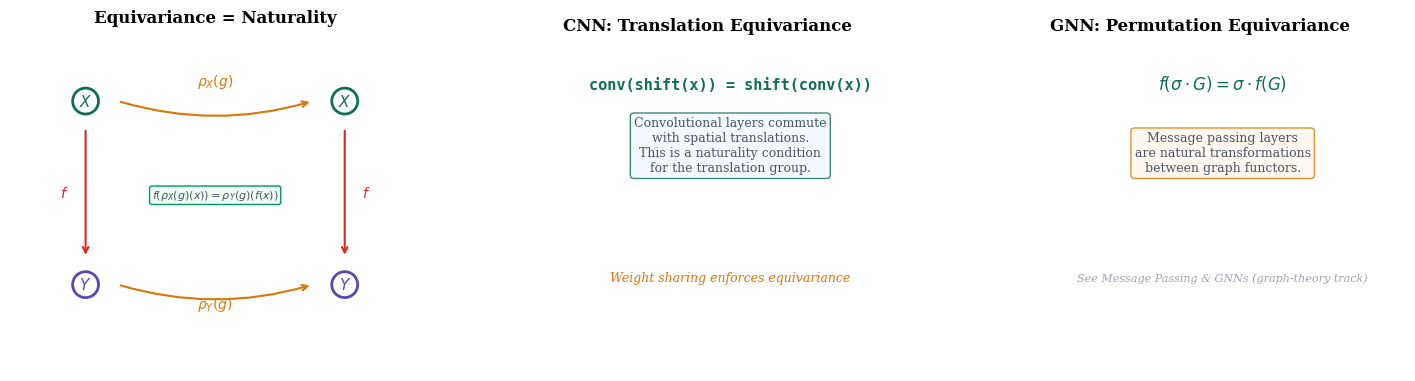

Figure 6: Equivariance as naturality -- ML connections


In [7]:
# === Equivariance as Naturality ===
# A function f: X -> Y is G-equivariant if f(g.x) = g.f(x).
# Categorically: G defines a one-object category BG.
# An action of G on X is a functor rho: BG -> Set (or Vec).
# G-equivariance means f is a natural transformation: f: rho_X => rho_Y.
#
# The naturality square IS the equivariance condition:
#   rho_X(g)       rho_Y(g)
# X -------> X   Y -------> Y
# |          |   |          |
# f|         |f  <- same f on both sides
#
# Examples in ML:
# 1. CNNs: translation-equivariant
# 2. GNNs: permutation-equivariant
# 3. Spherical CNNs: rotation-equivariant

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Panel 1: Equivariance = Naturality ---
ax = axes[0]
setup_diagram_axes(ax, xlim=(-0.3, 3.5), ylim=(-0.3, 2.8),
                   title='Equivariance = Naturality')

draw_object(ax, (0.4, 2.2), '$X$', COLORS['functor_F'], radius=0.12)
draw_object(ax, (2.8, 2.2), '$X$', COLORS['functor_F'], radius=0.12)
draw_object(ax, (0.4, 0.5), '$Y$', COLORS['functor_G'], radius=0.12)
draw_object(ax, (2.8, 0.5), '$Y$', COLORS['functor_G'], radius=0.12)

draw_arrow(ax, (0.7, 2.2), (2.5, 2.2), COLORS['accent'],
           label=r'$\rho_X(g)$', label_offset=(0, 0.18))
draw_arrow(ax, (0.7, 0.5), (2.5, 0.5), COLORS['accent'],
           label=r'$\rho_Y(g)$', label_offset=(0, -0.18))
draw_arrow(ax, (0.4, 1.95), (0.4, 0.75), COLORS['nat_trans'],
           label='$f$', label_offset=(-0.2, 0), connectionstyle='arc3,rad=0')
draw_arrow(ax, (2.8, 1.95), (2.8, 0.75), COLORS['nat_trans'],
           label='$f$', label_offset=(0.2, 0), connectionstyle='arc3,rad=0')

ax.text(1.6, 1.3, r'$f(\rho_X(g)(x)) = \rho_Y(g)(f(x))$', fontsize=8,
        ha='center', color=COLORS['neutral'],
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#F0FDF4',
                 edgecolor=COLORS['success']))

# --- Panel 2: CNN ---
ax = axes[1]
setup_diagram_axes(ax, xlim=(-0.5, 4.0), ylim=(-0.5, 3.0),
                   title='CNN: Translation Equivariance')

ax.text(2.0, 2.5, 'conv(shift(x)) = shift(conv(x))', fontsize=11,
        ha='center', color=COLORS['primary'], fontweight='bold',
        family='monospace')

ax.text(2.0, 1.6, 'Convolutional layers commute\nwith spatial translations.\n'
        'This is a naturality condition\nfor the translation group.',
        fontsize=9, ha='center', color=COLORS['neutral'],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#F0F9FF',
                 edgecolor=COLORS['primary'], alpha=0.8))

ax.text(2.0, 0.4, 'Weight sharing enforces equivariance',
        fontsize=9, ha='center', color=COLORS['accent'], style='italic')

# --- Panel 3: GNN ---
ax = axes[2]
setup_diagram_axes(ax, xlim=(-0.5, 4.0), ylim=(-0.5, 3.0),
                   title='GNN: Permutation Equivariance')

ax.text(2.0, 2.5, r'$f(\sigma \cdot G) = \sigma \cdot f(G)$', fontsize=12,
        ha='center', color=COLORS['primary'], fontweight='bold')

ax.text(2.0, 1.6, 'Message passing layers\nare natural transformations\n'
        'between graph functors.',
        fontsize=9, ha='center', color=COLORS['neutral'],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF7ED',
                 edgecolor=COLORS['accent'], alpha=0.8))

ax.text(2.0, 0.4, 'See Message Passing & GNNs (graph-theory track)',
        fontsize=8, ha='center', color=COLORS['muted'], style='italic')

plt.savefig('equivariance-ml.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 6: Equivariance as naturality -- ML connections")


---


In [8]:
# === Computational Notes ===
# Python representations and verification of natural transformations.

# --- Naturality verification for the double dual embedding ---
import numpy as np

# Let T: R^2 -> R^3 be a linear map
T = np.array([[1, 2], [3, 4], [5, 6]])

v = np.array([1.0, 0.0])

# In finite dims with chosen basis, the double dual embedding is
# the identity (V ~ V**). Naturality: T** . eta_V = eta_W . T
left_path = T @ v   # T**(eta_V(v)) = T(v)
right_path = T @ v  # eta_W(T(v)) = T(v)

print("=== Double Dual: Naturality Verification ===")
print(f"T = \n{T}")
print(f"v = {v}")
print(f"Left path  (T** . eta_V)(v) = {left_path}")
print(f"Right path (eta_W . T)(v)   = {right_path}")
print(f"Naturality holds: {np.allclose(left_path, right_path)}")

print()

# --- The trace as a natural transformation ---
# tr: End(-) => k is a natural transformation where
# End(V) = Hom(V, V) and k is the ground field.
# Naturality: for T: V -> W (invertible), tr(T M T^{-1}) = tr(M)

M = np.array([[1.0, 2.0], [3.0, 4.0]])  # Endomorphism of R^2
T_inv = np.array([[0.5, -0.5], [1.0, 0.5]])  # Invertible T
T_mat = np.linalg.inv(T_inv)

conjugated = T_mat @ M @ T_inv
print("=== Trace as Natural Transformation ===")
print(f"tr(M) = {np.trace(M):.4f}")
print(f"tr(T M T^(-1)) = {np.trace(conjugated):.4f}")
print(f"Equal: {np.isclose(np.trace(M), np.trace(conjugated))}")

print()

# --- Entropy and the data processing inequality ---
from scipy.stats import entropy as scipy_entropy

def entropy_bits(p):
    return scipy_entropy(p, base=2)

def pushforward(p, f_map, target_labels):
    q = {label: 0.0 for label in target_labels}
    for i, pi in enumerate(p):
        q[f_map[i]] += pi
    return np.array([q[label] for label in target_labels])

p = np.array([0.5, 0.3, 0.2])
f_map = {0: "a", 1: "b", 2: "a"}
f_star_p = pushforward(p, f_map, ["a", "b"])

H_p = entropy_bits(p)
H_f = entropy_bits(f_star_p)

print("=== Entropy as Natural Transformation ===")
print(f"p = {p} on {{1,2,3}}")
print(f"f: 1->a, 2->b, 3->a")
print(f"f_*(p) = {f_star_p} on {{a,b}}")
print(f"H(p) = {H_p:.4f} bits")
print(f"H(f_*(p)) = {H_f:.4f} bits")
print(f"H(p) >= H(f_*(p)): {H_p >= H_f - 1e-10}")
print("Deterministic functions cannot increase entropy.")

print()

# --- Vertical composition ---
print("=== Composition of Natural Transformations ===")
print("Vertical: (beta . alpha)_A = beta_A . alpha_A")
print("Horizontal: (beta * alpha)_A = beta_{G(A)} . F\'(alpha_A)")
print("Interchange: (d.g) * (b.a) = (d*b) . (g*a)")


=== Double Dual: Naturality Verification ===
T = 
[[1 2]
 [3 4]
 [5 6]]
v = [1. 0.]
Left path  (T** . eta_V)(v) = [1. 3. 5.]
Right path (eta_W . T)(v)   = [1. 3. 5.]
Naturality holds: True

=== Trace as Natural Transformation ===
tr(M) = 5.0000
tr(T M T^(-1)) = 5.0000
Equal: True

=== Entropy as Natural Transformation ===
p = [0.5 0.3 0.2] on {1,2,3}
f: 1->a, 2->b, 3->a
f_*(p) = [0.7 0.3] on {a,b}
H(p) = 1.4855 bits
H(f_*(p)) = 0.8813 bits
H(p) >= H(f_*(p)): True
Deterministic functions cannot increase entropy.

=== Composition of Natural Transformations ===
Vertical: (beta . alpha)_A = beta_A . alpha_A
Horizontal: (beta * alpha)_A = beta_{G(A)} . F'(alpha_A)
Interchange: (d.g) * (b.a) = (d*b) . (g*a)


---


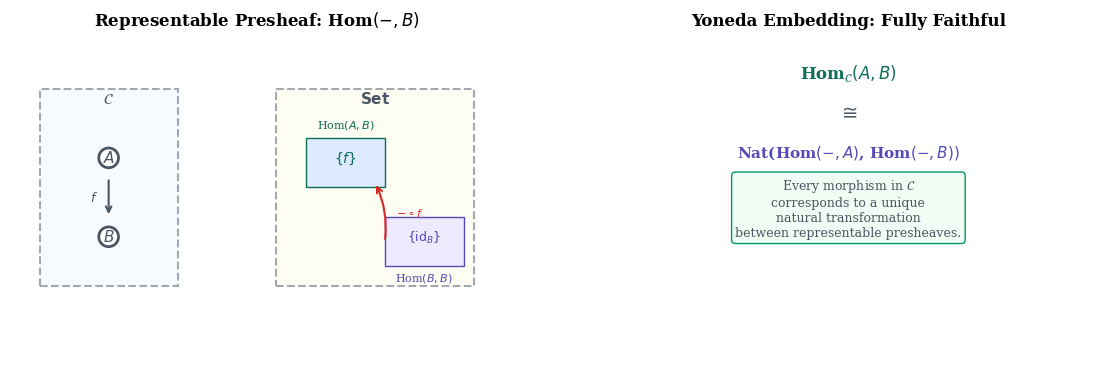

Figure 7: Presheaves and representability


In [9]:
# === Presheaves and Representability ===
# A presheaf on C is a functor F: C^op -> Set.
# F is representable if F ~ Hom(-, A) for some A.
# By Yoneda: Nat(Hom(-, A), F) ~ F(A).

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
setup_diagram_axes(ax, xlim=(-0.5, 4.5), ylim=(-0.3, 3.0),
                   title=r'Representable Presheaf: Hom$(-, B)$')

ax.add_patch(plt.Rectangle((-0.2, 0.5), 1.4, 2.0, fill=True,
              facecolor='#F0F9FF', edgecolor=COLORS['neutral'],
              linewidth=1.5, linestyle='--', alpha=0.5))
ax.text(0.5, 2.35, r'$\mathcal{C}$', fontsize=11, ha='center',
         color=COLORS['neutral'], fontweight='bold')

draw_object(ax, (0.5, 1.8), '$A$', COLORS['neutral'], radius=0.1)
draw_object(ax, (0.5, 1.0), '$B$', COLORS['neutral'], radius=0.1)
draw_arrow(ax, (0.5, 1.6), (0.5, 1.2), COLORS['neutral'],
           label='$f$', label_offset=(-0.15, 0), fontsize=9,
           connectionstyle='arc3,rad=0')

ax.add_patch(plt.Rectangle((2.2, 0.5), 2.0, 2.0, fill=True,
              facecolor='#FEFCE8', edgecolor=COLORS['neutral'],
              linewidth=1.5, linestyle='--', alpha=0.5))
ax.text(3.2, 2.35, r'$\mathbf{Set}$', fontsize=11, ha='center',
         color=COLORS['neutral'], fontweight='bold')

ax.add_patch(plt.Rectangle((2.5, 1.5), 0.8, 0.5, fill=True,
              facecolor='#DBEAFE', edgecolor=COLORS['functor_F'], linewidth=1))
ax.text(2.9, 1.75, r'$\{f\}$', fontsize=10, ha='center', color=COLORS['functor_F'])
ax.text(2.9, 2.1, r'Hom$(A,B)$', fontsize=8, ha='center',
         color=COLORS['functor_F'])

ax.add_patch(plt.Rectangle((3.3, 0.7), 0.8, 0.5, fill=True,
              facecolor='#EDE9FE', edgecolor=COLORS['functor_G'], linewidth=1))
ax.text(3.7, 0.95, r'$\{\mathrm{id}_B\}$', fontsize=9, ha='center',
         color=COLORS['functor_G'])
ax.text(3.7, 0.55, r'Hom$(B,B)$', fontsize=8, ha='center',
         color=COLORS['functor_G'])

draw_arrow(ax, (3.3, 0.95), (3.2, 1.55), COLORS['nat_trans'],
           label=r'$- \circ f$', label_offset=(0.3, 0), fontsize=8)

ax = axes[1]
setup_diagram_axes(ax, xlim=(-0.5, 4.5), ylim=(-0.3, 3.0),
                   title='Yoneda Embedding: Fully Faithful')

ax.text(2.0, 2.6, r'Hom$_\mathcal{C}(A, B)$', fontsize=12,
        ha='center', color=COLORS['primary'], fontweight='bold')
ax.text(2.0, 2.2, r'$\cong$', fontsize=14, ha='center', color=COLORS['neutral'])
ax.text(2.0, 1.8, r'Nat(Hom$(-, A)$, Hom$(-, B))$',
        fontsize=11, ha='center', color=COLORS['functor_G'], fontweight='bold')

ax.text(2.0, 1.0, 'Every morphism in $\\mathcal{C}$\ncorresponds to a unique\n'
        'natural transformation\nbetween representable presheaves.',
        fontsize=9, ha='center', color=COLORS['neutral'],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#F0FDF4',
                 edgecolor=COLORS['success']))

plt.savefig('presheaves-representability.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Figure 7: Presheaves and representability")


---


## Connections & Further Reading

### Cross-Track and Within-Track Connections

| Topic | Track | Connection |
|-------|-------|------------|
| [Categories & Functors](/topics/categories-functors) | Category Theory | Direct prerequisite. All definitions (categories, functors, morphisms, Hom sets) are assumed. The naturality condition is the next level of structure after the functor axioms. |
| [Shannon Entropy & Mutual Information](/topics/shannon-entropy) | Information Theory | Shannon entropy defines a natural transformation from the probability distribution functor to the reals. The data processing inequality follows from naturality. |
| [Message Passing & GNNs](/topics/message-passing) | Graph Theory | Message passing layers are natural transformations between graph functors. Permutation equivariance of GNNs is precisely the naturality condition for the symmetric group. |
| [The Spectral Theorem](/topics/spectral-theorem) | Linear Algebra | The double dual embedding $\eta_V: V \to V^{**}$ is the canonical natural transformation in **Vec**. The trace is a natural transformation from the endomorphism functor to the ground field. |
| [Measure-Theoretic Probability](/topics/measure-theoretic-probability) | Probability & Statistics | The Giry monad's unit (Dirac delta embedding) is a natural transformation. Conditioning and marginalization are natural transformations between probability functors. |
| **Adjunctions** *(coming soon)* | Category Theory | Adjunctions are defined via natural isomorphisms $\mathrm{Hom}(FA, B) \cong \mathrm{Hom}(A, GB)$. The unit and counit of an adjunction are natural transformations. |
| **Monads & Comonads** *(coming soon)* | Category Theory | A monad is a triple $(T, \eta, \mu)$ where $\eta: \mathrm{Id} \Rightarrow T$ and $\mu: T^2 \Rightarrow T$ are natural transformations satisfying associativity and unit laws. |

### Key References

1. **Mac Lane**, *Categories for the Working Mathematician* (1998) — Chapters IV-V on natural transformations, the Yoneda lemma, and functor categories.
2. **Awodey**, *Category Theory* (2010) — Chapter 7: natural transformations with examples from algebra.
3. **Riehl**, *Category Theory in Context* (2016) — Chapters 2-3 on natural transformations and the Yoneda lemma. Freely available online.
4. **Fong & Spivak**, *An Invitation to Applied Category Theory* (2019) — Applied examples of naturality.
5. **Shiebler, Gavranovic & Wilson**, *Category Theory in Machine Learning* (2021) — Equivariant networks as natural transformations.
6. **Bronstein et al.**, *Geometric Deep Learning* (2021) — Equivariance as a design principle.

### Notation Summary

| Symbol | Meaning |
|--------|---------|
| $\alpha: F \Rightarrow G$ | Natural transformation from $F$ to $G$ |
| $\alpha_A: F(A) \to G(A)$ | Component of $\alpha$ at object $A$ |
| $[\mathcal{C}, \mathcal{D}]$ or $\mathcal{D}^\mathcal{C}$ | Functor category |
| $\beta \circ \alpha$ | Vertical composition |
| $\beta * \alpha$ | Horizontal composition |
| $\alpha H$ | Right whiskering |
| $K \alpha$ | Left whiskering |
| $\mathrm{Nat}(F, G)$ | Set of natural transformations $F \to G$ |
| $F \cong G$ | Natural isomorphism |
| $\mathsf{y}$ | Yoneda embedding |
| $\mathrm{Hom}(A, -)$, $\mathrm{Hom}(-, A)$ | Representable functors |
